In [2]:
using Pkg; Pkg.add(["ITensors", "ITensorMPS", "Plots", "LsqFit", "Statistics", "LinearAlgebra", "ProgressMeter", "LaTeXStrings", "SavitzkyGolay"])
using ITensors, ITensorMPS, Plots, LsqFit, Statistics, LinearAlgebra, ProgressMeter, LaTeXStrings, SavitzkyGolay

include("../../data/params.jl")
include("../../data/helpers/saving.jl")
include("../schmidt_spectra/get_spectrum.jl")
include("../schmidt_spectra/deviation/deviation.jl")

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
  No Changes to `~/dev/uni/msciproject/Project.toml`
  No Changes to `~/dev/uni/msciproject/Manifest.toml`


find_deviation_idx (generic function with 1 method)

In [3]:
function fetch_states(
    N::Int, σ::Float64, system_params::Dict{String, Any};
    max::Union{Nothing, Int}=nothing, type::Symbol=:latest
)::Tuple{Vector{MPS}, Vector{MPS}}
    CURRENT_DIR = @__DIR__
    FP = extract_filename_from_system_params(system_params)
    MPS_FP = joinpath(CURRENT_DIR, "../../data/storage/perturb_sigma_$(σ)_$(FP).hd5")
    matches_cln = find_runs_by_params(MPS_FP, Dict{String, Any}("N"=>N, "σ"=>0.00); load_psi=true, instance_selection=type)
    matches_dis = find_runs_by_params(MPS_FP, Dict{String, Any}("N"=>N, "σ"=>σ); load_psi=true, instance_selection=type)

    cln_mpss = MPS[]
    dis_mpss = MPS[]

    for (cln, dis) in zip(matches_cln, matches_dis)
        if (cln.psi === nothing || dis.psi === nothing)
            continue
        end

        push!(cln_mpss, cln.psi)
        push!(dis_mpss, dis.psi)

        if max !== nothing && length(cln_mpss) >= max
            break
        end
    end

    return cln_mpss, dis_mpss
end

fetch_states (generic function with 1 method)

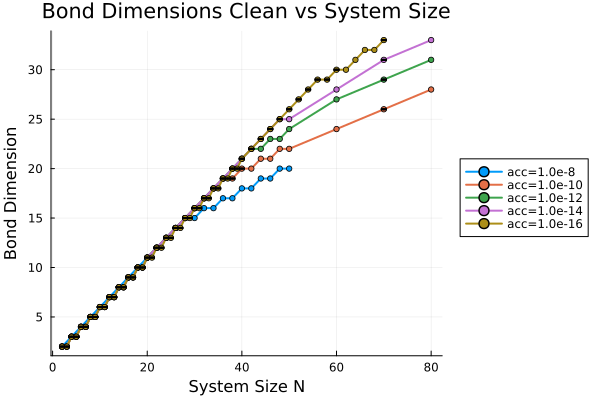

In [ ]:


Ns = 2:1:80;
σ = 5e-7;
accs = [1e-8, 1e-10, 1e-12, 1e-14, 1e-16]

p3 = plot(
             title="Bond Dimensions Clean vs System Size",
             xlabel="System Size N", ylabel="Bond Dimension",
             legend=:outerright, grid=true)

for (idx, acc) in enumerate(accs)
    bond_dims = Float64[]
    errs = Float64[]
    valid_Ns = Float64[]

    prog = Progress(length(accs); desc="σ=$σ")


    for N in Ns


    system_params = Dict{String,Any}(
                        "J" => -1.0,
                        "Δ" => -1.0,
                        "μ" => 1.0,
                        "NUM_SWEEPS" => 25,
                        "MAX_BOND_DIM" => 2000,
                        "ACC" => acc
                    )
        ψ0s, _ = fetch_states(N, σ, system_params; type=:all)
        if !isempty(ψ0s)
            bond_ds = [maxlinkdim(ps) for ps in ψ0s]
            push!(bond_dims, mean(bond_ds))
            push!(errs, std(bond_ds) / sqrt(length(bond_ds)))
            push!(valid_Ns, N)
        end
        next!(prog)
    end

    if !isempty(valid_Ns)
        plot!(p3, valid_Ns, bond_dims, yerr=errs,
              label="acc=$acc",
              color=idx,
              marker=:circle,
              markersize=3,
              linewidth=2)
    end
end

display(p3)

Fetching data... 100%|███████████████████████████████████| Time: 0:05:08


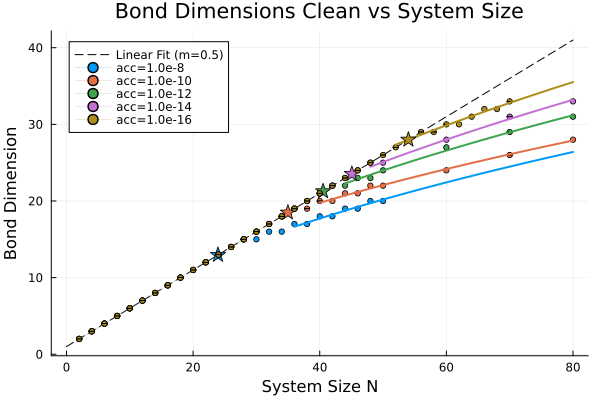

Intersection for acc=1.0e-8 occurs at N = 23.93
Intersection for acc=1.0e-10 occurs at N = 34.97
Intersection for acc=1.0e-12 occurs at N = 40.53
Intersection for acc=1.0e-14 occurs at N = 45.07
Intersection for acc=1.0e-16 occurs at N = 54.0


In [ ]:
using Plots
using ProgressMeter
using Statistics
using LsqFit

model_lin(x, p) = p[1] .* x .+ p[2]
model_sqrt(x, p) = p[1] .* sqrt.(x) .+ p[2]

Ns = 2:2:80
σ = 5e-7
accs = [1e-8, 1e-10, 1e-12, 1e-14, 1e-16]

all_data = Dict{Float64, Tuple{Vector{Float64}, Vector{Float64}, Vector{Float64}}}()

prog = Progress(length(accs); desc="Fetching data...")
for acc in accs
    bond_dims = Float64[]
    errs = Float64[]
    valid_Ns = Float64[]

    for N in Ns
        system_params = Dict{String,Any}(
            "J" => -1.0, "Δ" => -1.0, "μ" => 1.0,
            "NUM_SWEEPS" => 25, "MAX_BOND_DIM" => 2000, "ACC" => acc
        )

        ψ0s, _ = fetch_states(N, σ, system_params; type=:all)
        if !isempty(ψ0s)
            bond_ds = [maxlinkdim(ps) for ps in ψ0s]
            push!(bond_dims, mean(bond_ds))
            push!(errs, std(bond_ds) / sqrt(length(bond_ds)))
            push!(valid_Ns, N)
        end
    end
    all_data[acc] = (valid_Ns, bond_dims, errs)
    next!(prog)
end

p3 = plot(title="Bond Dimensions Clean vs System Size",
          xlabel="System Size N", ylabel="Bond Dimension",
          legend=:topleft, grid=true)

clean_Ns, clean_bonds, _ = all_data[1e-16]
lin_mask = clean_Ns .<= 25
lin_fit = curve_fit(model_lin, clean_Ns[lin_mask], clean_bonds[lin_mask], [0.5, 1.0])
m, c = lin_fit.param

plot!(p3, x -> model_lin(x, [m, c]), 0, 80, label="Linear Fit (m=$(round(m, digits=3)))", color=:black, linestyle=:dash)

for (idx, acc) in enumerate(accs)
    v_Ns, b_dims, b_errs = all_data[acc]

    plot!(p3, v_Ns, b_dims, yerr=b_errs, label="acc=$acc", color=idx, marker=:circle, markersize=3, linewidth=0)

    threshold = 20 - 2 * log10(acc)
    sqrt_mask = v_Ns .> threshold

    if count(sqrt_mask) > 3
        sqrt_fit = curve_fit(model_sqrt, v_Ns[sqrt_mask], b_dims[sqrt_mask], [5.0, 0.0])
        a, b = sqrt_fit.param

        plot!(p3, x -> model_sqrt(x, [a, b]), threshold, 80, label="", color=idx, linewidth=2)

        discriminant = a^2 - 4 * m * (c - b)
        if discriminant >= 0
            sqrt_N_int = (a + sqrt(discriminant)) / (2 * m)
            N_int = sqrt_N_int^2
            chi_int = model_lin(N_int, [m, c])

            scatter!(p3, [N_int], [chi_int], color=idx, markershape=:star5, markersize=8, label="")
            println("Intersection for acc=$acc occurs at N = $(round(N_int, digits=2))")
        end
    end
end

display(p3)

In [ ]:
sysparams = Dict{String,Any}(
    "J" => -1.0, "Δ" => -1.0, "μ" => 1.0,
    "NUM_SWEEPS" => 25, "MAX_BOND_DIM" => 2000, "ACC" => 10^-16
)

N = 60
σ = 1e-6

p = plot(title="Schmidt Spectra", ylabel="Schmidt Values Squared", legend=:topright,
    yscale=:log,
    # xscale=:log
)

cln, dis = fetch_states(N, σ, sysparams; type=:latest)
spectra = get_squared_sorted_schmidt_spectrum_from_mps(dis[1])
spectra_cln = get_squared_sorted_schmidt_spectrum_from_mps(cln[1])

plot!(p, 1:length(spectra), spectra)
plot!(p, 1:length(spectra_cln), spectra_cln)

display(p)

Progress: 100%|█████████████████████████████████████████| Time: 0:03:56
┌ Warning: scale log is unsupported with Plots.GRBackend().
│ Choose from: [:identity, :ln, :log10, :log2]
└ @ Plots /Users/jamesneville-rolfe/.julia/packages/Plots/GIume/src/args.jl:1590
┌ Warning: scale log is unsupported with Plots.GRBackend().
│ Choose from: [:identity, :ln, :log10, :log2]
└ @ Plots /Users/jamesneville-rolfe/.julia/packages/Plots/GIume/src/args.jl:1590
┌ Warning: scale log is unsupported with Plots.GRBackend().
│ Choose from: [:identity, :ln, :log10, :log2]
└ @ Plots /Users/jamesneville-rolfe/.julia/packages/Plots/GIume/src/args.jl:1590
┌ Warning: scale log is unsupported with Plots.GRBackend().
│ Choose from: [:identity, :ln, :log10, :log2]
└ @ Plots /Users/jamesneville-rolfe/.julia/packages/Plots/GIume/src/args.jl:1590
┌ Warning: scale log is unsupported with Plots.GRBackend().
│ Choose from: [:identity, :ln, :log10, :log2]
└ @ Plots /Users/jamesneville-rolfe/.julia/packages/Plots/GIume/src/a

Plots.AnimatedGif("/Users/jamesneville-rolfe/dev/uni/msciproject/programs/random/schmidt_ensemble_averages.gif")
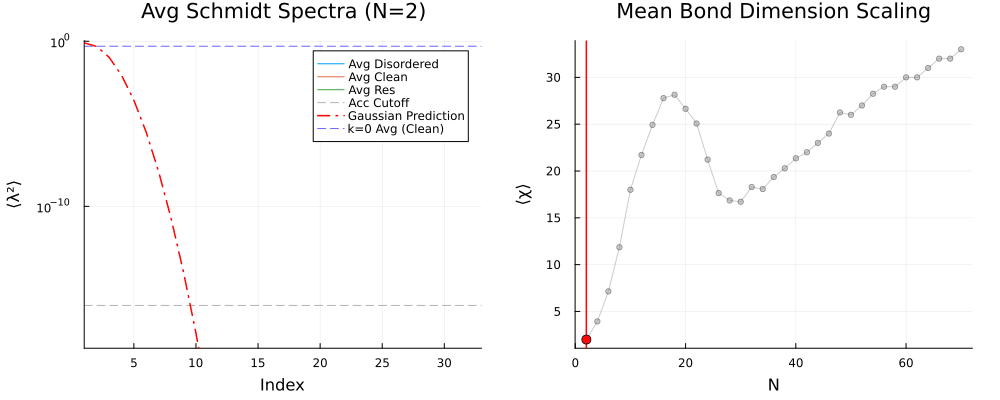

In [45]:
using Plots
using Statistics

sysparams = Dict{String,Any}(
    "J" => -1.0, "Δ" => -1.0, "μ" => 1.0,
    "NUM_SWEEPS" => 25, "MAX_BOND_DIM" => 2000, "ACC" => 10^-16
)

N_range = 2:2:80
σ = 5e-7

function get_residual_state(ψ_σ::MPS, ψ_0::MPS; normalize::Bool = true)
    ξ = inner(ψ_σ, ψ_0)
    ψ_r = ψ_σ - ξ * ψ_0
    if normalize normalize!(ψ_r) end
    return ψ_r
end

# Data Storage
avg_spectra_dis = Dict{Int, Vector{Float64}}()
avg_spectra_cln = Dict{Int, Vector{Float64}}()
avg_spectra_res = Dict{Int, Vector{Float64}}()
mean_bond_dims = Float64[]
valid_N = Int[]

# Global Limits
max_len_global = 0
min_schmidt_global = 1.0

@showprogress for n in N_range
    cln_list, dis_list = fetch_states(n, σ, sysparams; type=:all)
    if isempty(dis_list) || isempty(cln_list) continue end

    push!(valid_N, n)

    all_s_dis = [get_squared_sorted_schmidt_spectrum_from_mps(m) for m in dis_list]
    max_n_len = maximum(length.(all_s_dis))

    padded_dis = [vcat(s, zeros(max_n_len - length(s))) for s in all_s_dis]
    avg_dis = mean(padded_dis)
    avg_spectra_dis[n] = avg_dis

    push!(mean_bond_dims, mean([maxlinkdim(m) for m in dis_list]))

    all_s_cln = [get_squared_sorted_schmidt_spectrum_from_mps(m) for m in cln_list]
    avg_cln = mean([vcat(s, zeros(maximum(length.(all_s_cln)) - length(s))) for s in all_s_cln])
    avg_spectra_cln[n] = avg_cln

    max_len_global = max(max_len_global, length(avg_dis), length(avg_cln))

    all_s_res = [get_squared_sorted_schmidt_spectrum_from_mps(get_residual_state(d, c; normalize=false)) for (c, d) in zip(cln_list, dis_list)]
    avg_res = mean([vcat(s, zeros(maximum(length.(all_s_res)) - length(s))) for s in all_s_res])
    avg_spectra_res[n] = avg_res

    valid_vals = filter(x -> x > 1e-30, vcat(avg_dis, avg_cln))
    if !isempty(valid_vals)
        min_schmidt_global = min(min_schmidt_global, minimum(valid_vals))
    end
end

anim = @animate for (i, n) in enumerate(valid_N)
    s_dis = avg_spectra_dis[n]
    s_cln = avg_spectra_cln[n]
    s_res = avg_spectra_res[n]

    # avg schmidt spectra
    p1 = plot(
        1:length(s_dis), s_dis,
        label="Avg Disordered",
        title="Avg Schmidt Spectra (N=$n)",
        ylabel="⟨λ²⟩",
        xlabel="Index",
        yscale=:log,
        xlims=(1, max_len_global),
        ylims=(min_schmidt_global, 1.1),
        legend=:topright
    )
    plot!(p1, 1:length(s_cln), s_cln, label="Avg Clean")
    plot!(p1, 1:length(s_res), s_res, label="Avg Res")
    hline!(p1, [sysparams["ACC"]], label="Acc Cutoff", ls=:dash, lc=:black, alpha=0.3)

    σ_sq = (n^2) / (16 * (n - 1))
    peak_height = 1 / sqrt(2 * π * σ_sq)

    pred_indices = 1:max_len_global
    pred_vals = [peak_height * exp(-(( (idx-1)/2 )^2) / (2 * σ_sq)) for idx in pred_indices]

    plot!(p1, pred_indices, pred_vals,
        label="Gaussian Prediction",
        ls=:dashdot,
        lc=:red,
        lw=1.5
    )

    # Constants for residual weight scaling
    c_res = 0.3 # Calibration constant for β² = cσ²N
    β_sq = (c_res^2) * (σ^2) * n

    # Sector k=0: Clean State Average
    χ_cln = n/2 + 1
    hline!(p1, [1/χ_cln], label="k=0 Avg (Clean)", lc=:blue, ls=:dash, alpha=0.6)

    # Sector k=2: First Residual Band
    # D(N, N/2-2) ≈ N²/2
    num_k2 = (n * (n - 3)) / 2
    if num_k2 > 0
        hline!(p1, [β_sq / num_k2], label="k=2 Avg (Res)", lc=:green, ls=:dash, alpha=0.6)
    end

    # Sector k=3: Second Residual Band
    # D(N, N/2-3) ≈ N³/6
    num_k3 = (n * (n - 1) * (n - 5)) / 6
    if num_k3 > 0
        hline!(p1, [β_sq / num_k3], label="k=3 Avg (Res)", lc=:purple, ls=:dash, alpha=0.6)
    end

    # avg bond dim
    p2 = plot(
        valid_N, mean_bond_dims,
        xlabel="N",
        ylabel="⟨χ⟩",
        title="Mean Bond Dimension Scaling",
        marker=:circle, mc=:gray, ms=3, lc=:gray, alpha=0.4,
        legend=false
    )
    vline!(p2, [n], lc=:red, lw=1.5)
    scatter!(p2, [n], [mean_bond_dims[i]], mc=:red, ms=5)

    plot(p1, p2, layout=(1, 2), size=(1000, 400), margin=5Plots.mm)
end

gif(anim, "schmidt_ensemble_averages.gif", fps = 5)

Progress: 100%|█████████████████████████████████████████| Time: 0:04:34
┌ Info: Saved animation to /Users/jamesneville-rolfe/dev/uni/msciproject/programs/random/schmidt_ensemble_averages.gif
└ @ Plots /Users/jamesneville-rolfe/.julia/packages/Plots/GIume/src/animation.jl:156


Plots.AnimatedGif("/Users/jamesneville-rolfe/dev/uni/msciproject/programs/random/schmidt_ensemble_averages.gif")
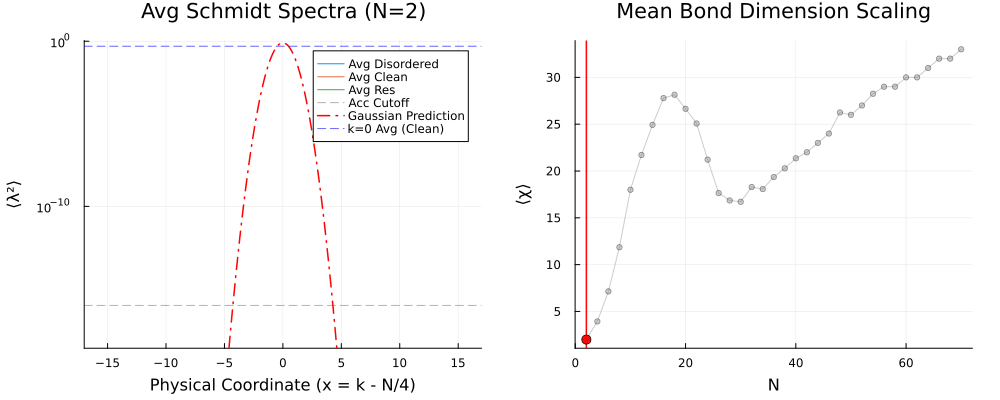

In [51]:
function unfold_spectrum(s::Vector{Float64})
    n_vals = length(s)
    x_vals = zeros(Int, n_vals)
    y_vals = zeros(Float64, n_vals)

    if n_vals > 0
        x_vals[1] = 0
        y_vals[1] = s[1]
    end

    for i in 2:n_vals
        step = div(i, 2)
        sgn = iseven(i) ? 1 : -1
        x_vals[i] = sgn * step
        y_vals[i] = s[i]
    end

    perm = sortperm(x_vals)
    return x_vals[perm], y_vals[perm]
end

using Plots
using Statistics

sysparams = Dict{String,Any}(
    "J" => -1.0, "Δ" => -1.0, "μ" => 1.0,
    "NUM_SWEEPS" => 25, "MAX_BOND_DIM" => 2000, "ACC" => 10^-16
)

N_range = 2:2:80
σ = 5e-7

function get_residual_state(ψ_σ::MPS, ψ_0::MPS; normalize::Bool = true)
    ξ = inner(ψ_σ, ψ_0)
    ψ_r = ψ_σ - ξ * ψ_0
    if normalize normalize!(ψ_r) end
    return ψ_r
end

# Data Storage
avg_spectra_dis = Dict{Int, Vector{Float64}}()
avg_spectra_cln = Dict{Int, Vector{Float64}}()
avg_spectra_res = Dict{Int, Vector{Float64}}()
mean_bond_dims = Float64[]
valid_N = Int[]

# Global Limits
max_len_global = 0
min_schmidt_global = 1.0

@showprogress for n in N_range
    cln_list, dis_list = fetch_states(n, σ, sysparams; type=:all)
    if isempty(dis_list) || isempty(cln_list) continue end

    push!(valid_N, n)

    all_s_dis = [get_squared_sorted_schmidt_spectrum_from_mps(m) for m in dis_list]
    max_n_len = maximum(length.(all_s_dis))

    padded_dis = [vcat(s, zeros(max_n_len - length(s))) for s in all_s_dis]
    avg_dis = mean(padded_dis)
    avg_spectra_dis[n] = avg_dis

    push!(mean_bond_dims, mean([maxlinkdim(m) for m in dis_list]))

    all_s_cln = [get_squared_sorted_schmidt_spectrum_from_mps(m) for m in cln_list]
    avg_cln = mean([vcat(s, zeros(maximum(length.(all_s_cln)) - length(s))) for s in all_s_cln])
    avg_spectra_cln[n] = avg_cln

    max_len_global = max(max_len_global, length(avg_dis), length(avg_cln))

    all_s_res = [get_squared_sorted_schmidt_spectrum_from_mps(get_residual_state(d, c; normalize=false)) for (c, d) in zip(cln_list, dis_list)]
    avg_res = mean([vcat(s, zeros(maximum(length.(all_s_res)) - length(s))) for s in all_s_res])
    avg_spectra_res[n] = avg_res

    valid_vals = filter(x -> x > 1e-30, vcat(avg_dis, avg_cln))
    if !isempty(valid_vals)
        min_schmidt_global = min(min_schmidt_global, minimum(valid_vals))
    end
end

anim = @animate for (i, n) in enumerate(valid_N)
    s_dis = avg_spectra_dis[n]
    s_cln = avg_spectra_cln[n]
    s_res = avg_spectra_res[n]

    x_dis, y_dis = unfold_spectrum(s_dis)
    x_cln, y_cln = unfold_spectrum(s_cln)
    x_res, y_res = unfold_spectrum(s_res)

    max_x = div(max_len_global, 2) + 1

    p1 = plot(
        x_dis, y_dis,
        label="Avg Disordered",
        title="Avg Schmidt Spectra (N=$n)",
        ylabel="⟨λ²⟩",
        xlabel="Physical Coordinate (x = k - N/4)",
        yscale=:log10,
        xlims=(-max_x, max_x),
        ylims=(min_schmidt_global, 1.1),
        legend=:topright
    )
    plot!(p1, x_cln, y_cln, label="Avg Clean")
    plot!(p1, x_res, y_res, label="Avg Res")
    hline!(p1, [sysparams["ACC"]], label="Acc Cutoff", ls=:dash, lc=:black, alpha=0.3)

    σ_sq = (n^2) / (16 * (n - 1))
    peak_height = 1 / sqrt(2 * π * σ_sq)

    pred_x = -max_x:0.1:max_x
    pred_vals = [peak_height * exp(-(x^2) / (2 * σ_sq)) for x in pred_x]

    plot!(p1, pred_x, pred_vals,
        label="Gaussian Prediction",
        ls=:dashdot,
        lc=:red,
        lw=1.5
    )

    c_res = 0.3
    β_sq = (c_res^2) * (σ^2) * n

    χ_cln = n/2 + 1
    hline!(p1, [1/χ_cln], label="k=0 Avg (Clean)", lc=:blue, ls=:dash, alpha=0.6)

    num_k2 = (n * (n - 3)) / 2
    if num_k2 > 0
        hline!(p1, [β_sq / num_k2], label="k=2 Avg (Res)", lc=:green, ls=:dash, alpha=0.6)
    end

    num_k3 = (n * (n - 1) * (n - 5)) / 6
    if num_k3 > 0
        hline!(p1, [β_sq / num_k3], label="k=3 Avg (Res)", lc=:purple, ls=:dash, alpha=0.6)
    end

    p2 = plot(
        valid_N, mean_bond_dims,
        xlabel="N",
        ylabel="⟨χ⟩",
        title="Mean Bond Dimension Scaling",
        marker=:circle, mc=:gray, ms=3, lc=:gray, alpha=0.4,
        legend=false
    )
    vline!(p2, [n], lc=:red, lw=1.5)
    scatter!(p2, [n], [mean_bond_dims[i]], mc=:red, ms=5)

    plot(p1, p2, layout=(1, 2), size=(1000, 400), margin=5Plots.mm)
end

gif(anim, "schmidt_ensemble_averages.gif", fps = 5)

In [49]:
using Plots

system_params = Dict{String,Any}(
    "J" => -1.0,
    "Δ" => -1.0,
    "μ" => 1.0,
    "NUM_SWEEPS" => 25,
    "MAX_BOND_DIM" => 2000,
    "ACC" => 1e-16
)

Ns = 2:1:80
σs = [5e-7, 7e-7, 9e-7]

p3 = plot(
    title="Bond Dimensions vs System Size",
    xlabel="System Size N", ylabel="Bond Dimension",
    legend=:outerright, grid=true
)

for (idx, σ) in enumerate(σs)
    bond_dims = Float64[]
    errs = Float64[]
    valid_Ns = Float64[]

    prog = Progress(length(Ns); desc="σ=$σ")

    for N in Ns
        ψ0s, ψσs = fetch_states(N, σ, system_params; type=:all)
        if !isempty(ψ0s) && !isempty(ψσs)
            bond_ds = [maxlinkdim(ps) - maxlinkdim(cs) for (cs, ps) in zip(ψ0s, ψσs)]
            push!(bond_dims, mean(bond_ds))
            push!(errs, std(bond_ds) / sqrt(length(bond_ds)))
            push!(valid_Ns, N)
        end
        next!(prog)
    end

    if !isempty(valid_Ns)
        plot!(p3, valid_Ns, bond_dims, yerr=errs,
            label="σ=$σ",
            color=idx,
            marker=:circle,
            markersize=3,
            linewidth=2
    )
    end
end



display(p3)

σ=5.0e-7  29%|████████████▌                              |  ETA: 0:01:28┌ Warning: Direct read into MPS failed for run 93 instance 5; attempting raw read for diagnostics.
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/data/helpers/saving.jl:559
┌ Info: Raw read type: Dict{String, Any}
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/data/helpers/saving.jl:566
┌ Info: Raw read keys: ["MPS[10]", "MPS[20]", "MPS[16]", "MPS[22]", "MPS[3]", "MPS[19]", "MPS[24]", "MPS[6]", "length", "MPS[8]", "MPS[23]", "MPS[13]", "MPS[18]", "MPS[9]", "MPS[15]", "MPS[1]", "MPS[25]", "MPS[17]", "MPS[4]", "MPS[11]", "MPS[14]", "MPS[12]", "llim", "MPS[2]", "MPS[7]", "MPS[21]", "MPS[5]", "rlim"]
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/data/helpers/saving.jl:568


InterruptException: InterruptException:

Progress: 100%|█████████████████████████████████████████| Time: 0:00:12
Progress: 100%|█████████████████████████████████████████| Time: 0:00:11
Progress: 100%|█████████████████████████████████████████| Time: 0:00:13
Progress: 100%|█████████████████████████████████████████| Time: 0:00:07


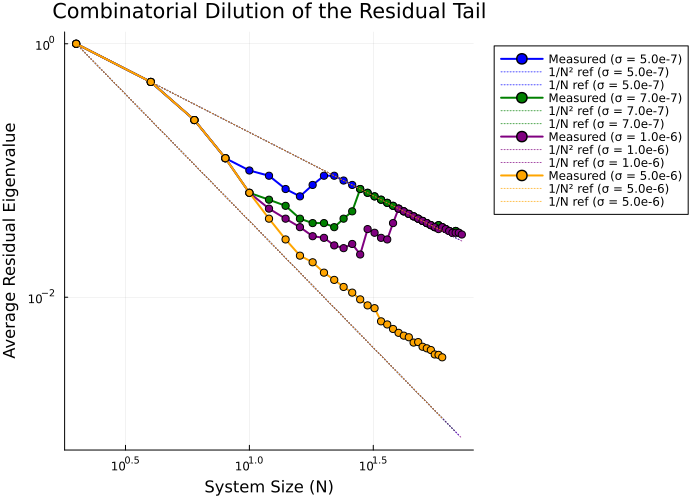

In [19]:
function get_residual_state(ψ_σ::MPS, ψ_0::MPS; normalize::Bool = true)
    ξ = inner(ψ_σ, ψ_0)
    ψ_r = ψ_σ - ξ * ψ_0
    if normalize normalize!(ψ_r) end
    return ψ_r
end

sysparams = Dict{String,Any}(
    "J" => -1.0,
    "Δ" => -1.0,
    "μ" => 1.0,
    "NUM_SWEEPS" => 25,
    "MAX_BOND_DIM" => 2000,
    "ACC" => 1e-16
)

function measure_dilution_scaling(N_values, σ_val::Float64, sysparams::Dict)
    avg_residual_eigenvalues = Float64[]
    valid_ns = []

    @showprogress for N in N_values
        # 1. Fetch the exact states
        cln_states, dis_states = fetch_states(N, σ_val, sysparams; type=:latest)
        if (!isempty(cln_states) && !isempty(dis_states))
            ψ_0 = cln_states[1]
            ψ_σ = dis_states[1]
            ψ_r = get_residual_state(ψ_σ, ψ_0; normalize=true)
            s_r = get_squared_sorted_schmidt_spectrum_from_mps(ψ_r)
            λ_r = s_r
            push!(avg_residual_eigenvalues, mean(λ_r))
            push!(valid_ns, N)
        end
    end

    return avg_residual_eigenvalues, valid_ns
end

N_vals = 2:2:80
σ_tests = [5e-7, 7e-7, 1e-6, 5e-6]

p_lambda = plot(
    xaxis=:log10, yaxis=:log10,
    xlabel="System Size (N)",
    ylabel="Average Residual Eigenvalue",
    title="Combinatorial Dilution of the Residual Tail",
    legend=:outertopright,
    size=(700, 500)
)

colors = [:blue, :green, :purple, :orange, :red]

for (i, σ_val) in enumerate(σ_tests)
    avg_λ, valid_ns = measure_dilution_scaling(N_vals, σ_val, sysparams)

    if isempty(valid_ns)
        println("No data found for σ = $σ_val, skipping...")
        continue
    end

    plot!(p_lambda, valid_ns, avg_λ,
        marker=:circle, lw=2, color=colors[i],
        label="Measured (σ = $σ_val)"
    )

    ref_line_n1 = [avg_λ[1] * (valid_ns[1]/n) for n in valid_ns]
    ref_line_n2 = [avg_λ[1] * (valid_ns[1]/n)^2 for n in valid_ns]
    plot!(p_lambda, valid_ns, ref_line_n2,
        ls=:dot, color=colors[i], alpha=0.7,
        label="1/N² ref (σ = $σ_val)"
    )

    plot!(p_lambda, valid_ns, ref_line_n1,
        ls=:dot, color=colors[i], alpha=0.7,
        label="1/N ref (σ = $σ_val)"
    )
end

savefig(p_lambda, "dilution_scaling_multi.png")
p_lambda

Progress: 100%|█████████████████████████████████████████| Time: 0:01:00


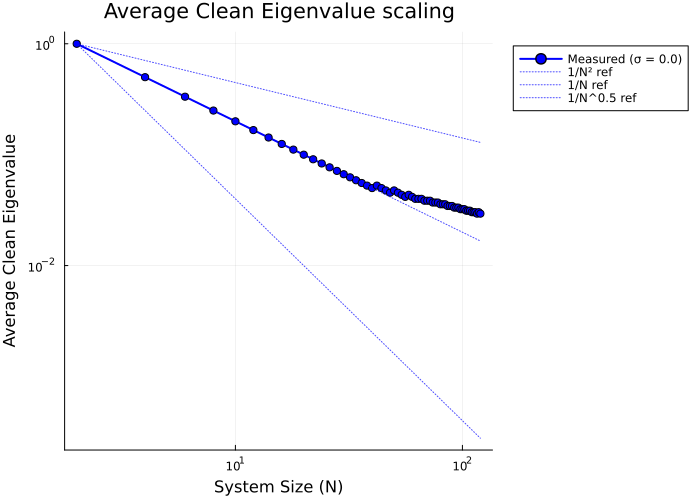

In [38]:
function get_residual_state(ψ_σ::MPS, ψ_0::MPS; normalize::Bool = true)
    ξ = inner(ψ_σ, ψ_0)
    ψ_r = ψ_σ - ξ * ψ_0
    if normalize normalize!(ψ_r) end
    return ψ_r
end

sysparams = Dict{String,Any}(
    "J" => -1.0,
    "Δ" => -1.0,
    "μ" => 1.0,
    "NUM_SWEEPS" => 25,
    "MAX_BOND_DIM" => 2000,
    "ACC" => 1e-10
)

function measure_dilution_scaling(N_values, σ_val::Float64, sysparams::Dict)
    avg_residual_eigenvalues = Float64[]
    valid_ns = []

    @showprogress for N in N_values
        # 1. Fetch the exact states
        cln_states, dis_states = fetch_states(N, σ_val, sysparams; type=:latest)
        if (!isempty(cln_states) && !isempty(dis_states))
            ψ_0 = cln_states[1]
            s_r = get_squared_sorted_schmidt_spectrum_from_mps(ψ_0)
            λ_r = s_r
            push!(avg_residual_eigenvalues, mean(λ_r))
            push!(valid_ns, N)
        end
    end

    return avg_residual_eigenvalues, valid_ns
end

N_vals = 2:2:120
σ_tests = [0.0]

p_lambda = plot(
    xaxis=:log10, yaxis=:log10,
    xlabel="System Size (N)",
    ylabel="Average Clean Eigenvalue",
    title="Average Clean Eigenvalue scaling",
    legend=:outertopright,
    size=(700, 500)
)

colors = [:blue, :green, :purple, :orange, :red]

for (i, σ_val) in enumerate(σ_tests)
    avg_λ, valid_ns = measure_dilution_scaling(N_vals, σ_val, sysparams)

    if isempty(valid_ns)
        println("No data found for σ = $σ_val, skipping...")
        continue
    end

    plot!(p_lambda, valid_ns, avg_λ,
        marker=:circle, lw=2, color=colors[i],
        label="Measured (σ = $σ_val)"
    )

    ref_line_n12 = [avg_λ[1] * (valid_ns[1]/n)^0.5 for n in valid_ns]
    ref_line_n1 = [avg_λ[1] * (valid_ns[1]/n) for n in valid_ns]
    ref_line_n2 = [avg_λ[1] * (valid_ns[1]/n)^2 for n in valid_ns]

    plot!(p_lambda, valid_ns, ref_line_n2,
        ls=:dot, color=colors[i], alpha=0.7,
        label="1/N² ref"
    )

    plot!(p_lambda, valid_ns, ref_line_n1,
        ls=:dot, color=colors[i], alpha=0.7,
        label="1/N ref"
    )

    plot!(p_lambda, valid_ns, ref_line_n12,
        ls=:dot, color=colors[i], alpha=0.7,
        label="1/N^0.5 ref"
    )
end

savefig(p_lambda, "dilution_scaling_multi.png")
p_lambda

Progress: 100%|█████████████████████████████████████████| Time: 0:00:46


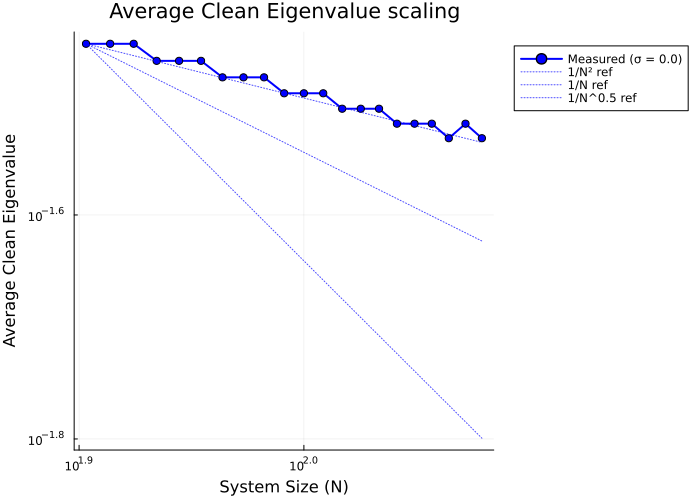

In [39]:
function get_residual_state(ψ_σ::MPS, ψ_0::MPS; normalize::Bool = true)
    ξ = inner(ψ_σ, ψ_0)
    ψ_r = ψ_σ - ξ * ψ_0
    if normalize normalize!(ψ_r) end
    return ψ_r
end

sysparams = Dict{String,Any}(
    "J" => -1.0,
    "Δ" => -1.0,
    "μ" => 1.0,
    "NUM_SWEEPS" => 25,
    "MAX_BOND_DIM" => 2000,
    "ACC" => 1e-10
)

function measure_dilution_scaling(N_values, σ_val::Float64, sysparams::Dict)
    avg_residual_eigenvalues = Float64[]
    valid_ns = []

    @showprogress for N in N_values
        # 1. Fetch the exact states
        cln_states, dis_states = fetch_states(N, σ_val, sysparams; type=:latest)
        if (!isempty(cln_states) && !isempty(dis_states))
            ψ_0 = cln_states[1]
            s_r = get_squared_sorted_schmidt_spectrum_from_mps(ψ_0)
            λ_r = s_r
            push!(avg_residual_eigenvalues, mean(λ_r))
            push!(valid_ns, N)
        end
    end

    return avg_residual_eigenvalues, valid_ns
end

N_vals = 80:2:120
σ_tests = [0.0]

p_lambda = plot(
    xaxis=:log10, yaxis=:log10,
    xlabel="System Size (N)",
    ylabel="Average Clean Eigenvalue",
    title="Average Clean Eigenvalue scaling",
    legend=:outertopright,
    size=(700, 500)
)

colors = [:blue, :green, :purple, :orange, :red]

for (i, σ_val) in enumerate(σ_tests)
    avg_λ, valid_ns = measure_dilution_scaling(N_vals, σ_val, sysparams)

    if isempty(valid_ns)
        println("No data found for σ = $σ_val, skipping...")
        continue
    end

    plot!(p_lambda, valid_ns, avg_λ,
        marker=:circle, lw=2, color=colors[i],
        label="Measured (σ = $σ_val)"
    )

    ref_line_n12 = [avg_λ[1] * (valid_ns[1]/n)^0.5 for n in valid_ns]
    ref_line_n1 = [avg_λ[1] * (valid_ns[1]/n) for n in valid_ns]
    ref_line_n2 = [avg_λ[1] * (valid_ns[1]/n)^2 for n in valid_ns]

    plot!(p_lambda, valid_ns, ref_line_n2,
        ls=:dot, color=colors[i], alpha=0.7,
        label="1/N² ref"
    )

    plot!(p_lambda, valid_ns, ref_line_n1,
        ls=:dot, color=colors[i], alpha=0.7,
        label="1/N ref"
    )

    plot!(p_lambda, valid_ns, ref_line_n12,
        ls=:dot, color=colors[i], alpha=0.7,
        label="1/N^0.5 ref"
    )
end

savefig(p_lambda, "dilution_scaling_multi.png")
p_lambda